In [1]:
import cv2
import time
import torch

from ultralytics import YOLO

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
if torch.cuda.is_available():
    print("GPU Available")
    print(torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

GPU Available
NVIDIA GeForce GTX 1650


In [3]:
model = YOLO("yolo11n.pt")

print("YOLO11 model loaded")

YOLO11 model loaded


In [4]:
print("Number of classes:", len(model.names))

print(model.names)

Number of classes: 80
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'ce

In [5]:
camera_id = 0

cap = cv2.VideoCapture(camera_id)


if not cap.isOpened():
    raise RuntimeError("Cannot open webcam")


print("Webcam opened successfully")

Webcam opened successfully


In [6]:
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
camera_fps = cap.get(cv2.CAP_PROP_FPS)


print("Width:", width)
print("Height:", height)
print("FPS:", camera_fps)

Width: 640
Height: 480
FPS: -1.0


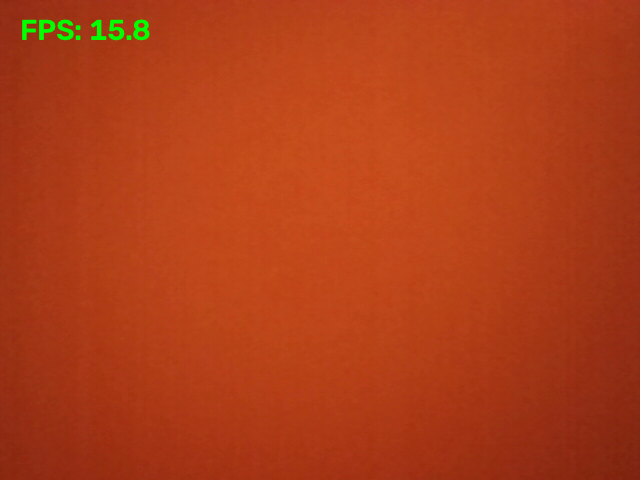

In [ ]:
import cv2
import time
from IPython.display import display, clear_output
from PIL import Image


previous_time = 0


while True:

    success, frame = cap.read()

    if not success:
        break


    results = model.predict(
        frame,
        conf=0.35,
        device=0,
        verbose=False
    )


    annotated_frame = results[0].plot()


    # FPS
    current_time = time.time()

    fps = 1 / (current_time - previous_time)

    previous_time = current_time


    cv2.putText(
        annotated_frame,
        f"FPS: {fps:.1f}",
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,0),
        2
    )


    # Convert BGR -> RGB
    frame_rgb = cv2.cvtColor(
        annotated_frame,
        cv2.COLOR_BGR2RGB
    )


    # Display inside notebook
    clear_output(wait=True)

    display(
        Image.fromarray(frame_rgb)
    )


    # stop with keyboard interrupt

In [ ]:
cap.release()

try:
    cv2.destroyAllWindows()
except:
    pass

print("Camera released")

Camera released


In [ ]:
output_path = "traffic_recording.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    output_path,
    fourcc,
    20,
    (width,height)
)

print("Video writer created")

Video writer created
